# BrushCue Example: Grayscale Gradient

<a href="https://colab.research.google.com/github/ditotechnologies/brushcue/blob/main/examples/grayscale_gradient.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

You can use this tool online at https://www.brushcue.com/tools/grayscale-gradient

In [ ]:
!pip install brushcue

[wgpu] using backend Metal — adapter 'Apple M5' (IntegratedGpu), driver ''


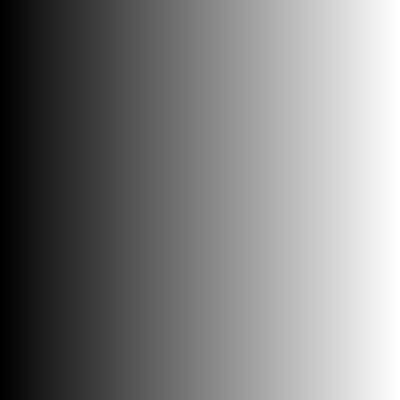

In [1]:
import io
from PIL import Image

import brushcue as bc

width = 1024
width_f = bc.Int.to_float(width)
height = 1024
height_f = bc.Int.to_float(height)
angle_degrees = 0.0
graph = bc.Composition.freeform_shader(
    "let angle_rad = angle_degrees * 0.0174532925;\nlet dir = vec2<f32>(cos(angle_rad), sin(angle_rad));\nlet size = vec2<f32>(width_f, height_f);\nlet proj = dot(canvas_position, dir);\nlet c1 = dot(vec2<f32>(0.0, 0.0), dir);\nlet c2 = dot(vec2<f32>(size.x, 0.0), dir);\nlet c3 = dot(vec2<f32>(0.0, size.y), dir);\nlet c4 = dot(vec2<f32>(size.x, size.y), dir);\nlet lo = min(min(c1, c2), min(c3, c4));\nlet hi = max(max(c1, c2), max(c3, c4));\nlet t = clamp((proj - lo) / max(hi - lo, 0.00001), 0.0, 1.0);\nreturn vec4<f32>(t, t, t, 1.0);",
    "",
    bc.Bounds2f.from_x_y_width_height(0.0, 0.0, width_f, height_f),
    bc.ColorRepresentation.srgb(),
    bc.Dictionary.create()
    .add("angle_degrees", angle_degrees)
    .add("width_f", width_f)
    .add("height_f", height_f),
)

ctx = bc.Context()
composition = graph.execute(ctx)
data_bytes = composition.to_image_bytes(ctx)
img = Image.open(io.BytesIO(data_bytes))
img.thumbnail((400, 400))  # Remove this line for full resolution
img
